In [189]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


In [190]:
tips = sns.load_dataset('tips')
tips.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [191]:
x = tips[['total_bill','size']]
y = tips['tip']

In [192]:
df = pd.DataFrame({
    'Experience': [1,2,3,4,5,6,7,8,9,10,
                   11,12,13,14,15,16,17,18,19,20],

    'Salary': [15,20,25,30,35,40,45,50,55,60,
               65,70,75,80,85,90,95,100,105,110]
})

print(df)

    Experience  Salary
0            1      15
1            2      20
2            3      25
3            4      30
4            5      35
5            6      40
6            7      45
7            8      50
8            9      55
9           10      60
10          11      65
11          12      70
12          13      75
13          14      80
14          15      85
15          16      90
16          17      95
17          18     100
18          19     105
19          20     110


In [193]:
x = df[['Experience']]
y = df['Salary']

In [194]:
# x =tips[['total_bill']]  
# y = tips['tip']

Text(0.5, 1.0, 'Total Bill vs Tip')

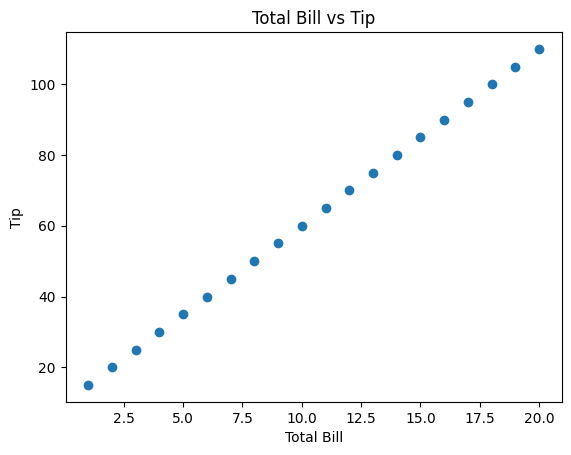

In [195]:

plt.scatter(x, y)
plt.xlabel('Total Bill')
plt.ylabel('Tip')
plt.title('Total Bill vs Tip')

In [196]:
# train test split
from sklearn.model_selection import train_test_split

In [197]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [198]:
from sklearn.linear_model import LinearRegression

In [199]:
model = LinearRegression()
model

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [200]:
model.fit(x_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [201]:
y_test

0      15
17    100
15     90
1      20
Name: Salary, dtype: int64

In [202]:
y_pred = model.predict(x_test)
y_pred

array([ 15., 100.,  90.,  20.])

In [203]:
from sklearn.metrics import mean_squared_error,mean_absolute_error,root_mean_squared_error,r2_score
print(f"{mean_squared_error(y_test,y_pred)}")
print(f"{mean_absolute_error(y_test,y_pred)}")
print(f"{root_mean_squared_error(y_test,y_pred)}")
print(f"{r2_score(y_test,y_pred)}")

2.524354896707238e-29
3.552713678800501e-15
5.0242958677880805e-15
1.0


In [204]:
r2 = r2_score(y_test,y_pred)
r2

1.0

In [205]:
n = x_test.shape[0]     # number of rows
p = x_test.shape[1]     # number of features

adjusted_r2 = 1 - ((1 - r2) * (n - 1) / (n - p - 1))

print("Adjusted R²:", adjusted_r2)

Adjusted R²: 1.0


Text(0.5, 1.0, 'Total Bill vs Tip with Regression Line')

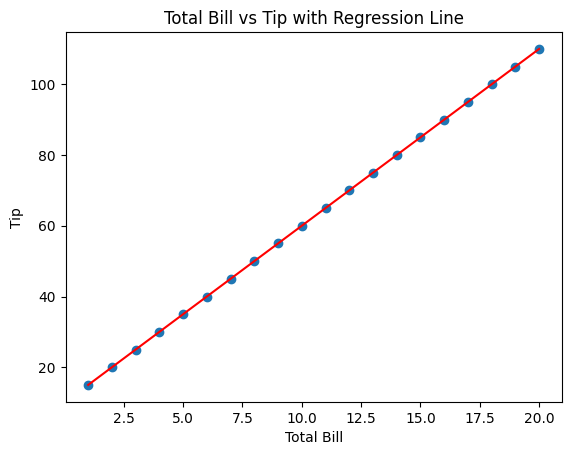

In [206]:
# regression line
plt.scatter(x, y)
plt.plot(x, model.predict(x), color='red')  # regression line
plt.xlabel('Total Bill')
plt.ylabel('Tip')
plt.title('Total Bill vs Tip with Regression Line')